In [ ]:
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    VotingRegressor, 
    StackingRegressor
)
import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from functions import (
    split_time_series_data,
    create_master_dataset,
    prepare_feature_matrices,
    
    plot_stock_trends,
    plot_decomposition_grid,
    plot_ticker_performance_comparison,
    
    run_stationarity_tests,
    clean_and_verify_stationarity,
    plot_differencing_comparison,
    plot_acf_grid,
    plot_pacf_grid,
    
    create_master_dataset,
    prepare_feature_matrices, 

    plot_model_comparison, 
    plot_ticker_performance_comparison, 
    get_best_params_for_model, 

    clean_params, 
    evaluate_ensemble,

    plot_kaplan_meier,
    plot_ticker_survival_comparison,
    plot_rsf_predictions,
    
    prep_ranking_data,
    pairwise_accuracy
)

Downloading the data.

In [2]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]

Loading the data.

In [4]:
data = pd.read_csv("stocks_data.csv", header=[0, 1], index_col=0, parse_dates=True)

print(data['Close'].head())

Ticker          AAPL    AMZN      GOOGL  META       MSFT
Date                                                    
2010-01-04  6.406479  6.6950  15.555865   NaN  23.077381
2010-01-05  6.417556  6.7345  15.487363   NaN  23.084841
2010-01-06  6.315477  6.6125  15.096946   NaN  22.943167
2010-01-07  6.303802  6.5000  14.745495   NaN  22.704557
2010-01-08  6.345711  6.6760  14.942070   NaN  22.861145


Splitting the data.

In [8]:
train_df_raw, val_df_raw, test_df_raw = split_time_series_data(data)

Total Rows: 4085
Train Size: 2859 (70.0%)
Val Size:   613 (15.0%)
Test Size:  613 (15.0%)


In [9]:
train_df_raw.isnull().sum()

Price   Ticker
Close   AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
High    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Low     AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Open    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Volume  AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
dtype: int64

In [10]:
print(train_df_raw['High']['META'].head(600))

Date
2010-01-04         NaN
2010-01-05         NaN
2010-01-06         NaN
2010-01-07         NaN
2010-01-08         NaN
                ...   
2012-05-14         NaN
2012-05-15         NaN
2012-05-16         NaN
2012-05-17         NaN
2012-05-18    44.64961
Name: META, Length: 600, dtype: float64


Plotting High Stock Prices

Since the 'High'column is of continuous data type we will use line graph to visualize it.

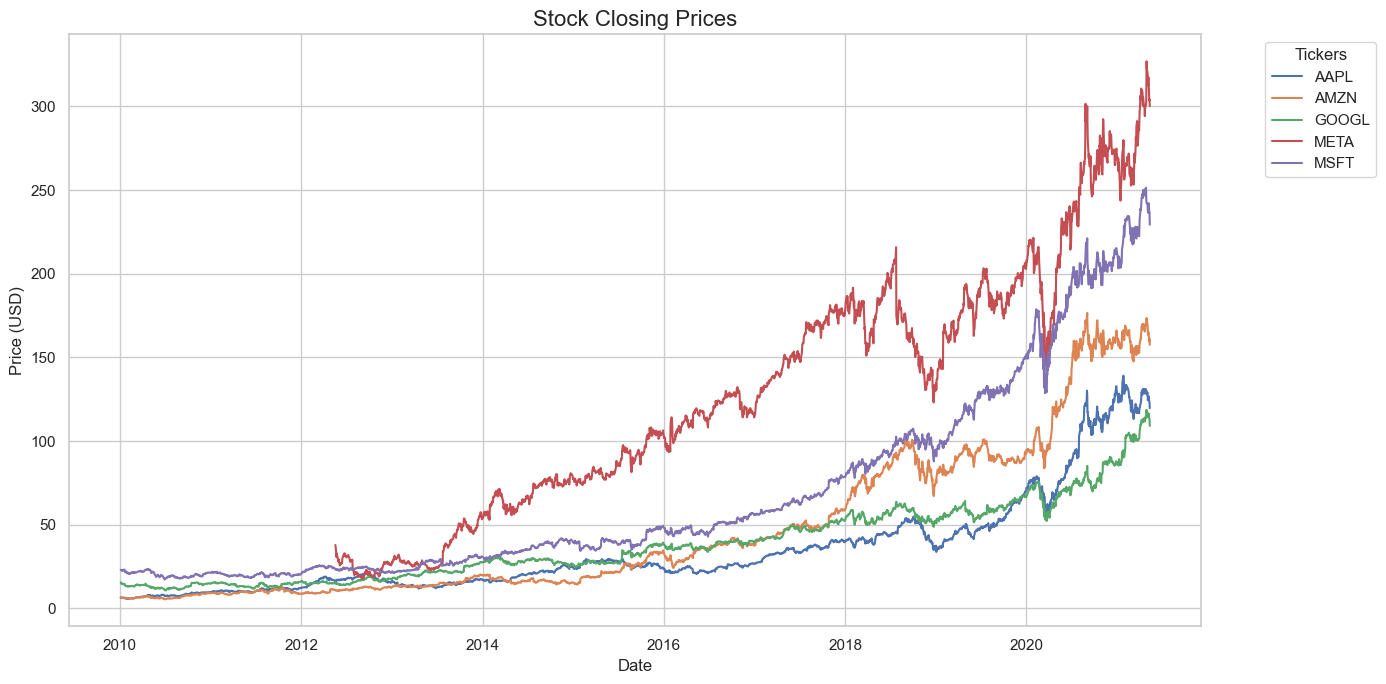

In [12]:
plot_stock_trends(train_df_raw, title='Stock Closing Prices')

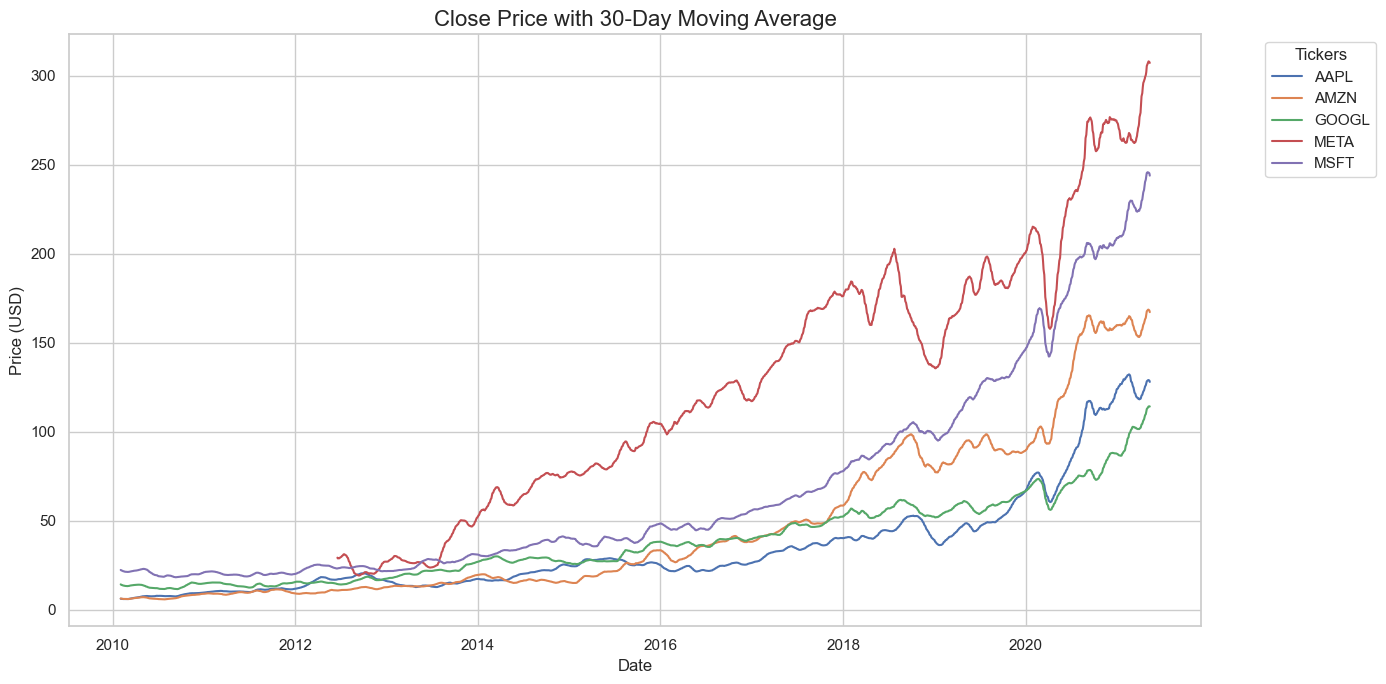

In [14]:
plot_stock_trends(train_df_raw, window=21, title='Stock Closing Prices with 30-Day Moving Average')

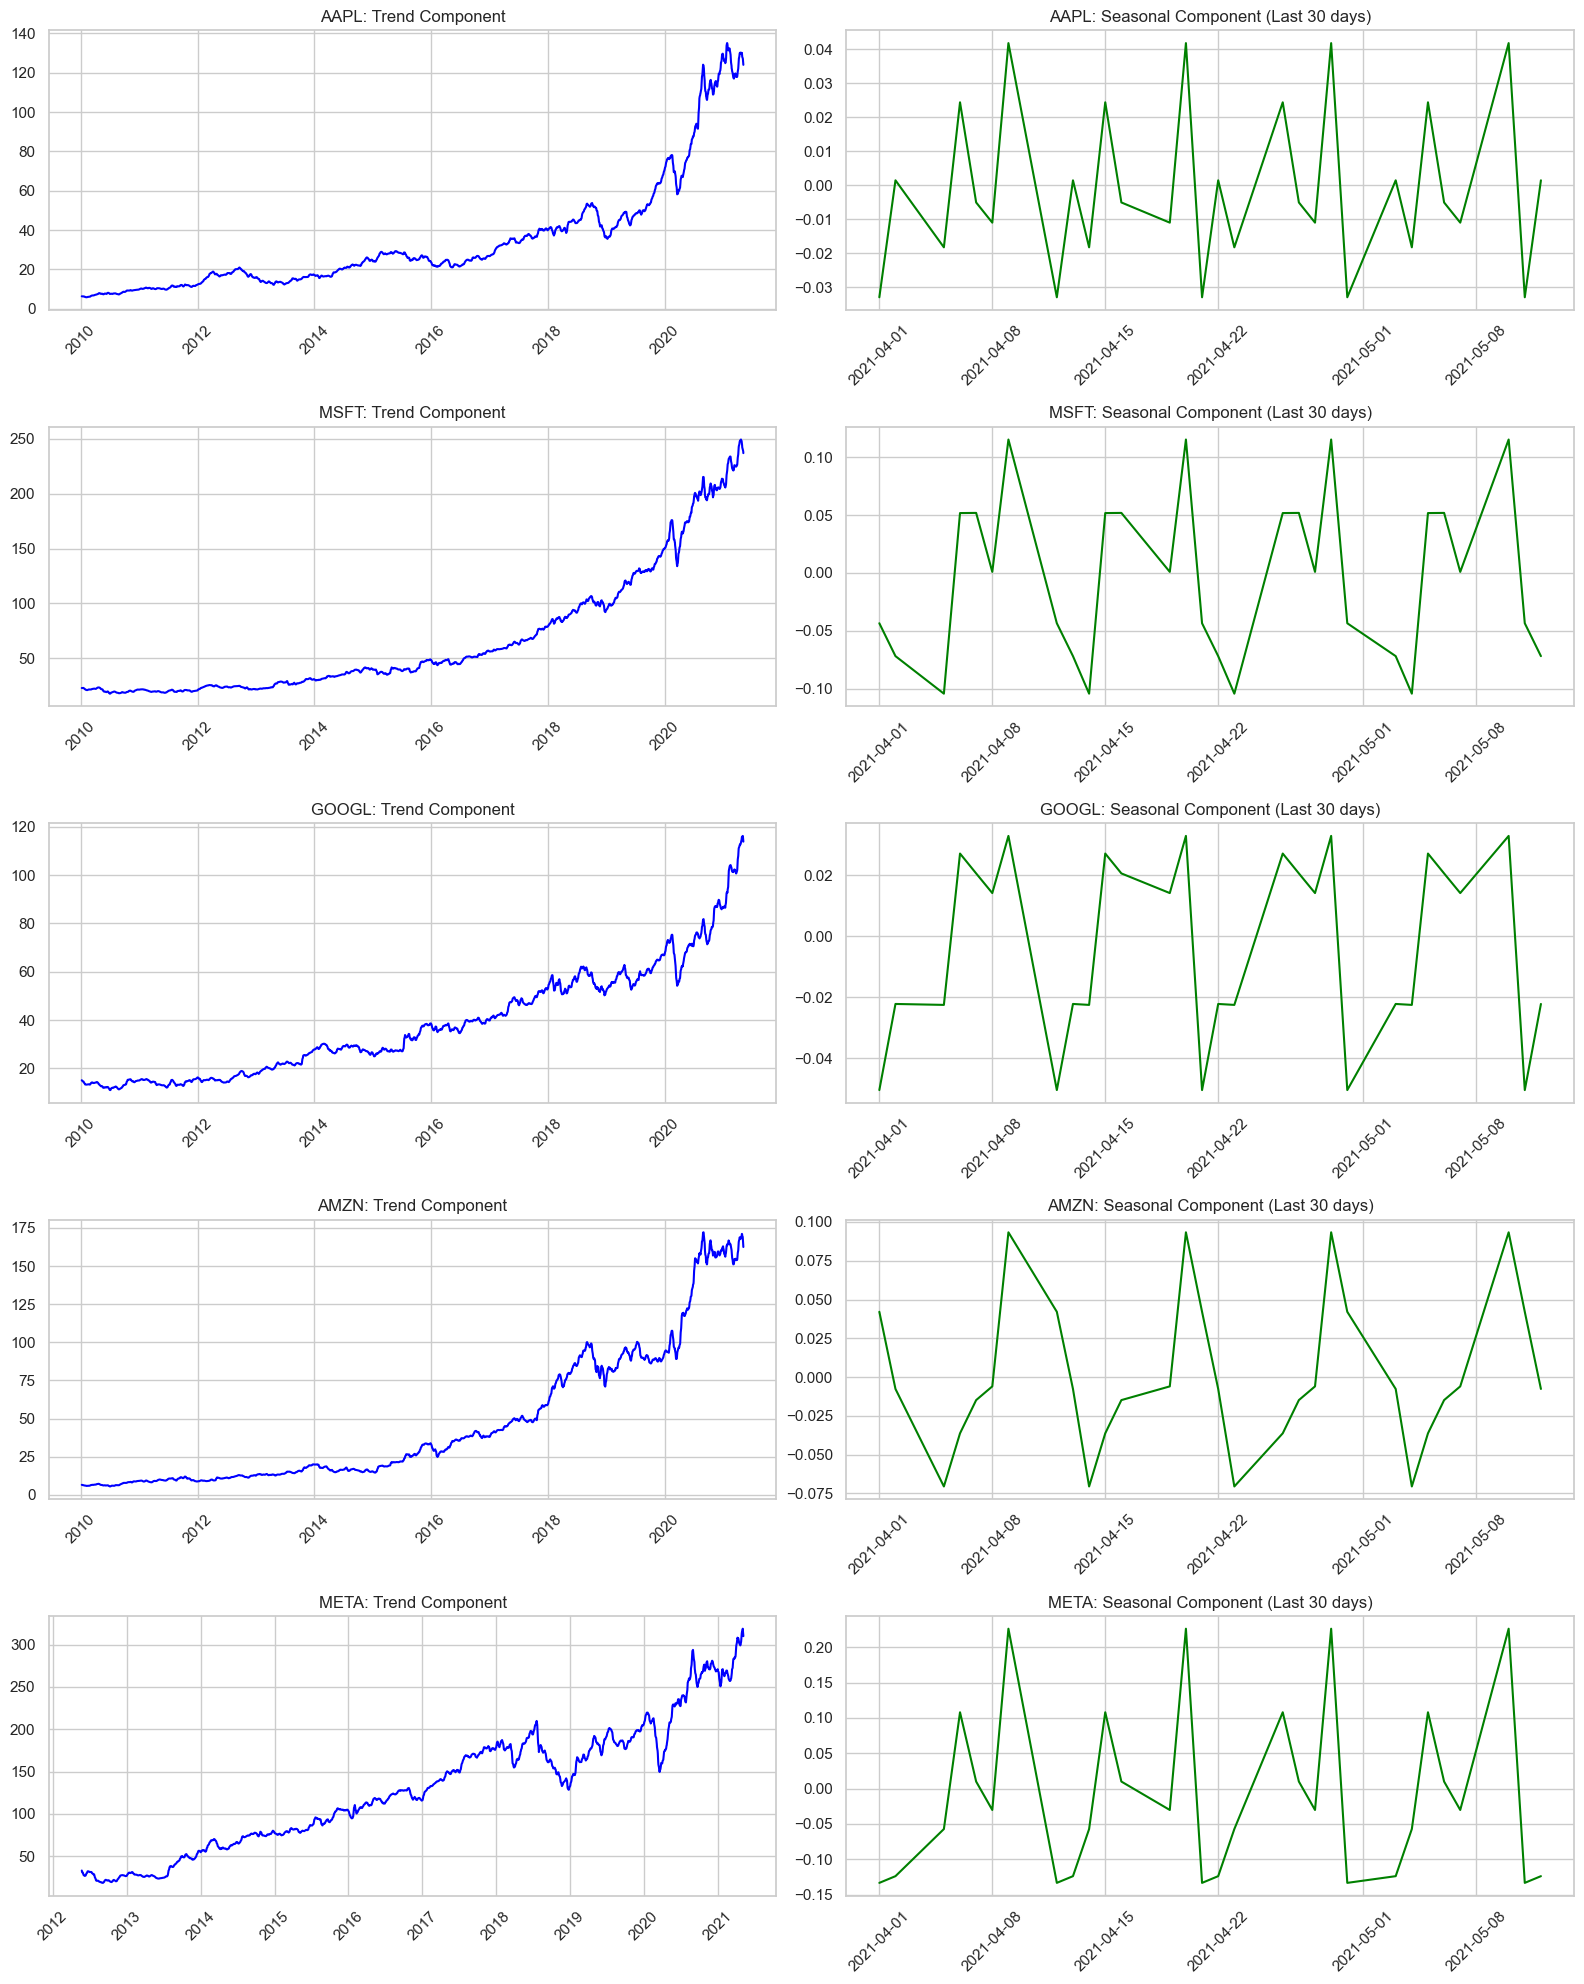

In [16]:
plot_decomposition_grid(train_df_raw, tickers)

Stocks have no seasonality, the pattern is just a mathematical noise, since the scale is very small comparing to the scale in the trend line.

Resampling Data

To better understand the trend of the data we will use the resampling method which provide a clearer view of trends and patterns when we are dealing with daily data.

Detecting Seasonality with Autocorrelation

We will detect Seasonality using the autocorrelation function (ACF) plot. Peaks at regular intervals in the ACF plot suggest the presence of seasonality.

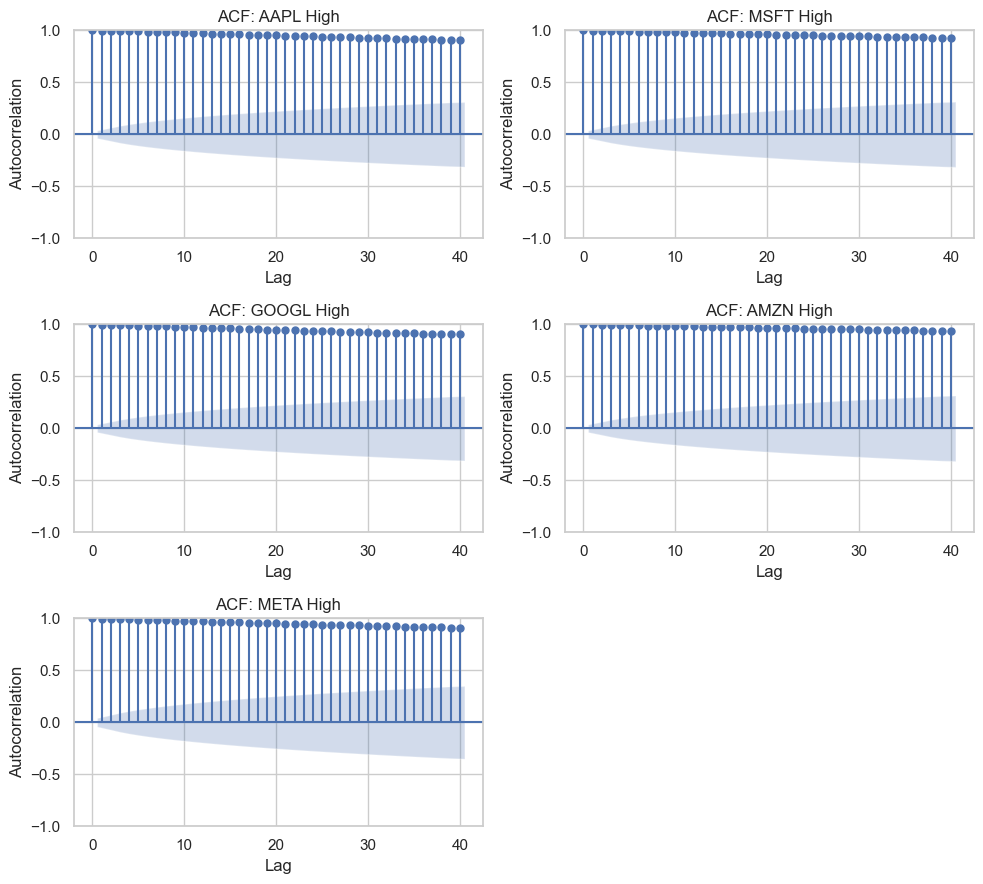

In [20]:
plot_acf_grid(train_df_raw, tickers, lags=40, column='High')

The data is not stationary, we should not rely on seasonality for this raw stock data.

Testing Stationarity with ADF test

We will perform the ADF test to formally test for stationarity.

In [22]:
run_stationarity_tests(train_df_raw, tickers)

ADF Test Results for AAPL High
ADF Statistic: 1.7154
p-value: 0.9982
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

The series is Non-Stationary.

ADF Test Results for MSFT High
ADF Statistic: 5.1223
p-value: 1.0000
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

The series is Non-Stationary.

ADF Test Results for GOOGL High
ADF Statistic: 2.4763
p-value: 0.9990
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

The series is Non-Stationary.

ADF Test Results for AMZN High
ADF Statistic: 2.0124
p-value: 0.9987
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

The series is Non-Stationary.

ADF Test Results for META High
ADF Statistic: 0.3459
p-value: 0.9794
Critical Values:
   1%: -3.4333
   5%: -2.8628
   10%: -2.5675

The series is Non-Stationary.



Based on the ADF Statistic we accept the null hypothesis, indicating that the data is not stationary according to the Augmented Dickey-Fuller test.
This suggests that differencing or other transformations may be needed to achieve stationarity before applying certain time series models.

Differencing to Achieve Stationarity

Differencing involves subtracting the previous observation from the current observation to remove trends or seasonality. 

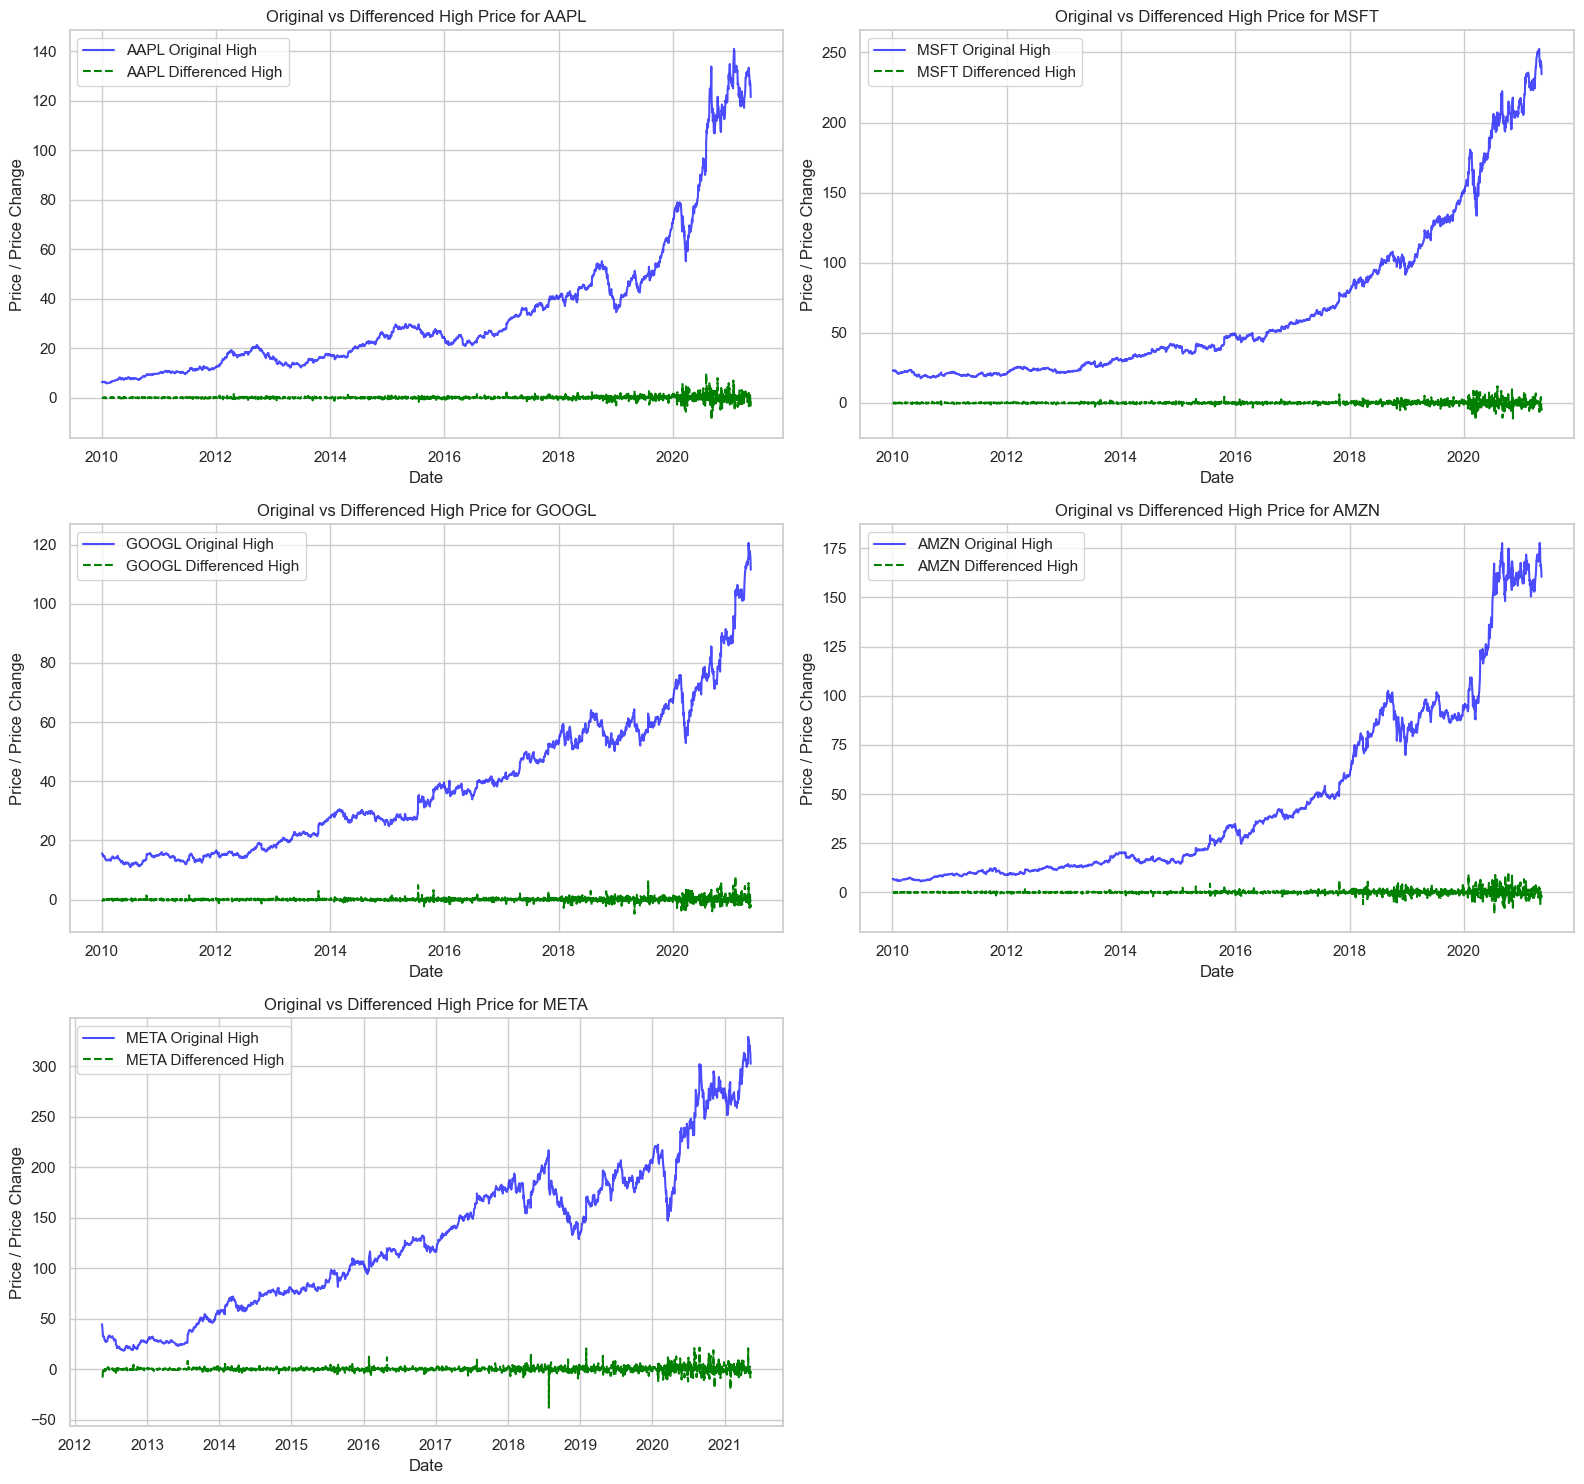

In [34]:
plot_differencing_comparison(train_df_raw, tickers)

Original Data vs. Differenced Data

In [ ]:
cleaned_train_dfs = clean_and_verify_stationarity(train_df_raw, tickers)

TICKER: AAPL
ADF Statistic: -10.4551
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: MSFT
ADF Statistic: -13.8919
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: GOOGL
ADF Statistic: -11.5973
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: AMZN
ADF Statistic: -11.5161
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: META
ADF Statistic: -9.7374
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: AAPL
ADF Statistic: -22.9291
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: MSFT
ADF Statistic: -17.8403
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: GOOGL
ADF Statistic: -22.0507
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: AMZN
ADF Statistic: -22.2896
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: META
ADF Statistic: -22.8621
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: AAPL
ADF Statistic: -12.6898
p-value: 0.0000
Result

In [ ]:
cleaned_val_dfs = clean_and_verify_stationarity(val_df_raw, tickers)

In [ ]:
cleaned_test_dfs = clean_and_verify_stationarity(test_df_raw, tickers)

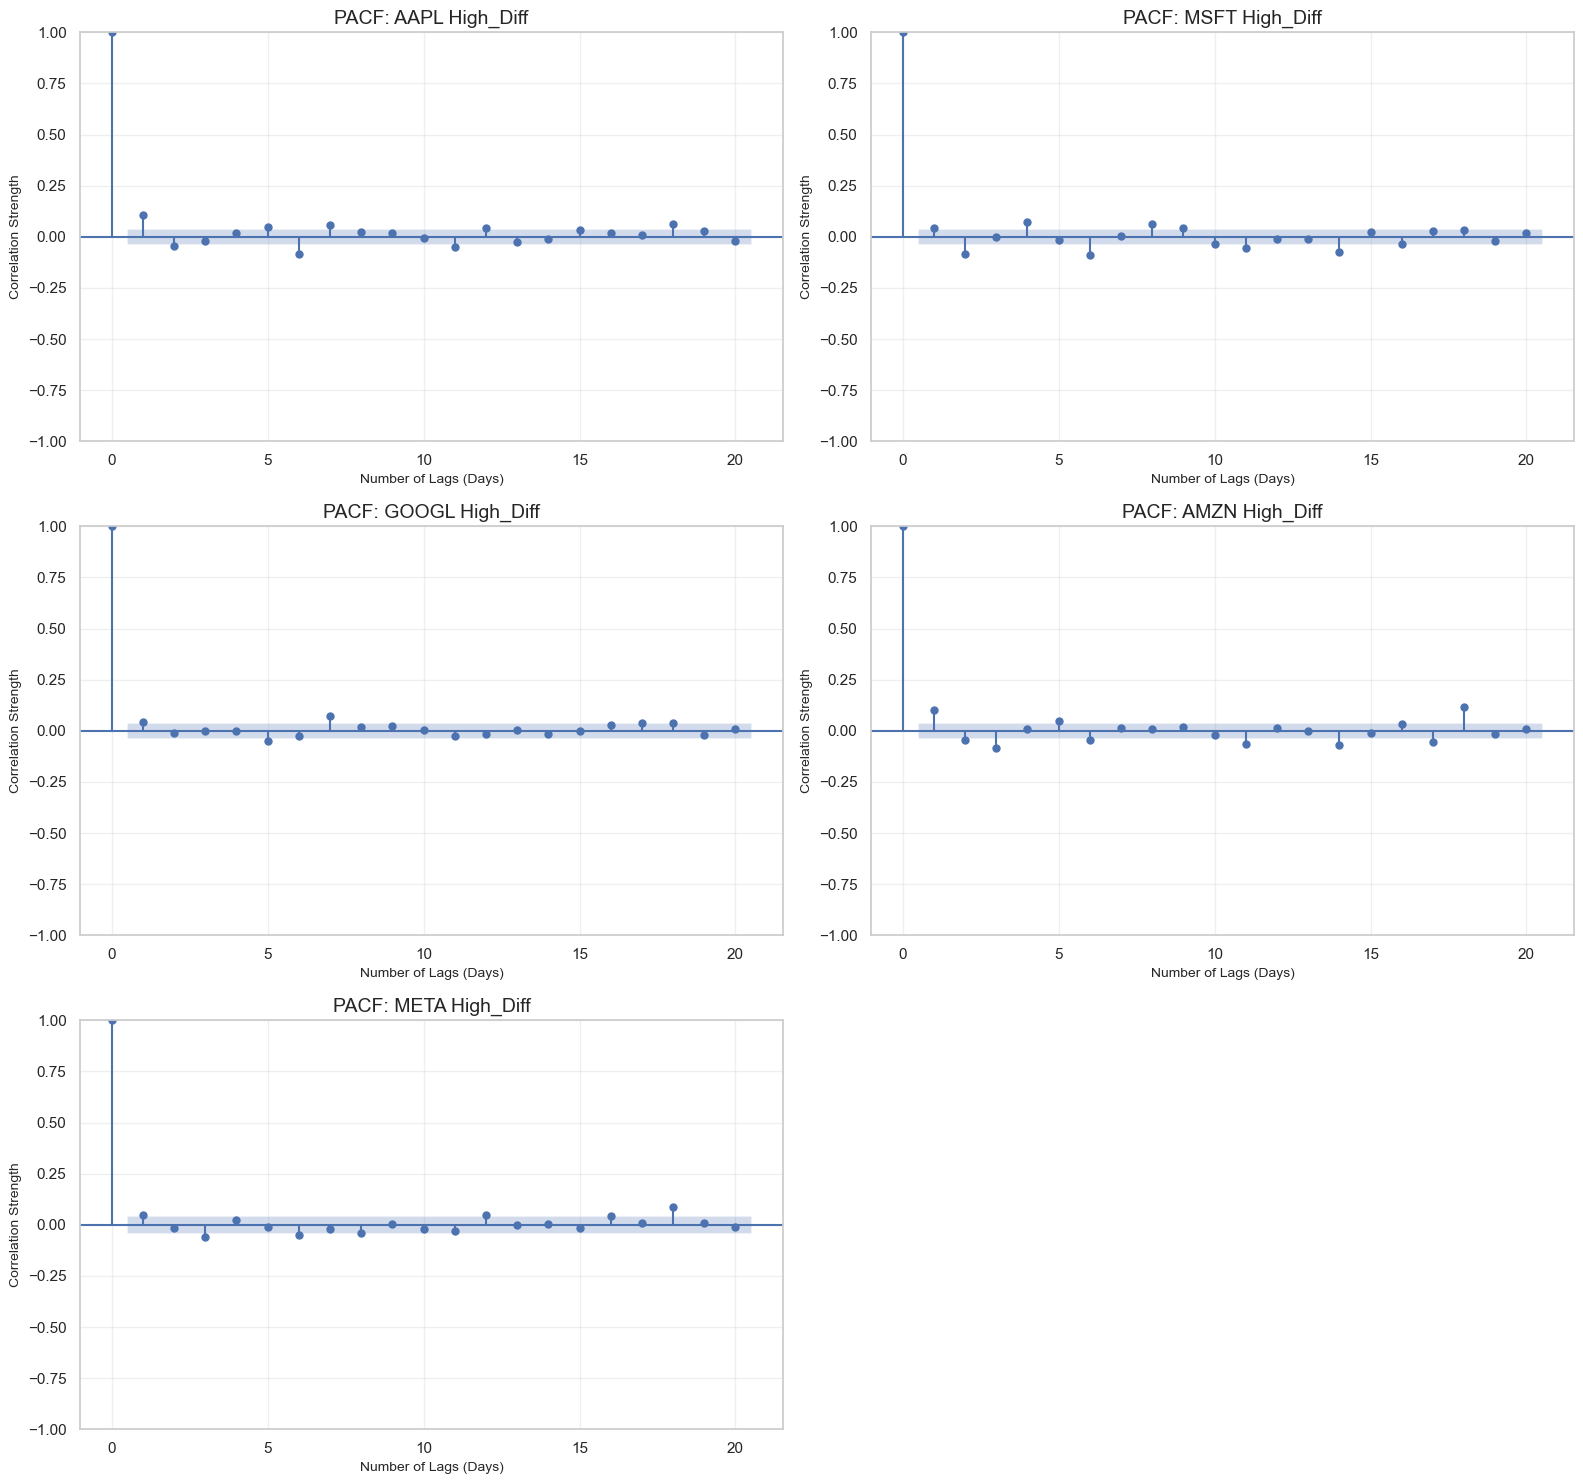

In [38]:
plot_pacf_grid(cleaned_train_dfs, tickers, lags=20)

The best number of lags:
- 6 - AAPL
- 2/4/6/8 - MSFT
- 7 - GOOGL
- 3 - AMZN
- 3/18 - META

I will choose 7 days lag.

Based on the ADF Statistic we reject the null hypothesis and conclude that we have enough evidence to reject the null hypothesis

# Time series forecasting

In [40]:
master_train_df = create_master_dataset(cleaned_train_dfs)
print(master_train_df[['Ticker', 'Vol_7d', 'RSI', 'Target', 'Relative_Performance']].head())
print(master_train_df[['Ticker', 'Vol_7d', 'RSI', 'Target']].head())

           Ticker    Vol_7d        RSI    Target  Relative_Performance
Date                                                                  
2010-02-02   AAPL  0.152741  34.925000  0.116152              0.082230
2010-02-03   AAPL  0.163224  38.664864 -0.054784             -0.019121
2010-02-04   AAPL  0.102120  37.584829 -0.070947              0.029409
2010-02-05   AAPL  0.101436  34.375093  0.056279              0.049221
2010-02-08   AAPL  0.101290  32.047432 -0.011375             -0.015125
           Ticker    Vol_7d        RSI    Target
Date                                            
2010-02-02   AAPL  0.152741  34.925000  0.116152
2010-02-03   AAPL  0.163224  38.664864 -0.054784
2010-02-04   AAPL  0.102120  37.584829 -0.070947
2010-02-05   AAPL  0.101436  34.375093  0.056279
2010-02-08   AAPL  0.101290  32.047432 -0.011375


In [41]:
master_val_df = create_master_dataset(cleaned_val_dfs)
print(master_val_df[['Ticker', 'Vol_7d', 'RSI', 'Target', 'Relative_Performance']].head())
print(master_val_df[['Ticker', 'Vol_7d', 'RSI', 'Target']].head())

           Ticker    Vol_7d        RSI    Target  Relative_Performance
Date                                                                  
2021-06-11   AAPL  1.056025  47.177498  3.021746             -0.775238
2021-06-14   AAPL  1.410670  60.030975  0.058476              1.089167
2021-06-15   AAPL  1.416072  59.019025  0.282700             -0.761340
2021-06-16   AAPL  1.409972  64.583350  1.618056              0.465815
2021-06-17   AAPL  1.339103  68.307236 -1.013768              0.149290
           Ticker    Vol_7d        RSI    Target
Date                                            
2021-06-11   AAPL  1.056025  47.177498  3.021746
2021-06-14   AAPL  1.410670  60.030975  0.058476
2021-06-15   AAPL  1.416072  59.019025  0.282700
2021-06-16   AAPL  1.409972  64.583350  1.618056
2021-06-17   AAPL  1.339103  68.307236 -1.013768


In [42]:
master_test_df = create_master_dataset(cleaned_test_dfs)
print(master_test_df[['Ticker', 'Vol_7d', 'RSI', 'Target', 'Relative_Performance']].head())
print(master_test_df[['Ticker', 'Vol_7d', 'RSI', 'Target']].head())

           Ticker    Vol_7d        RSI    Target  Relative_Performance
Date                                                                  
2023-11-16   AAPL  1.023822  93.134905 -0.573490              1.639465
2023-11-17   AAPL  1.235485  90.268640  1.512859             -0.403959
2023-11-20   AAPL  1.237024  91.813640 -0.385637             -1.337574
2023-11-21   AAPL  1.142533  89.006813  1.394229              1.016298
2023-11-22   AAPL  1.021721  87.851649 -2.007276             -1.368138
           Ticker    Vol_7d        RSI    Target
Date                                            
2023-11-16   AAPL  1.023822  93.134905 -0.573490
2023-11-17   AAPL  1.235485  90.268640  1.512859
2023-11-20   AAPL  1.237024  91.813640 -0.385637
2023-11-21   AAPL  1.142533  89.006813  1.394229
2023-11-22   AAPL  1.021721  87.851649 -2.007276


In [44]:
X_train, y_train = prepare_feature_matrices(master_train_df)
X_val, y_val = prepare_feature_matrices(master_val_df)
X_test, y_test = prepare_feature_matrices(master_test_df)

In [45]:
numeric_features = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 
    'Vol_7d', 'Dist_SMA_20', 'RSI', 'Vol_ZScore', 'MACD', 
    'BB_Percent', 'Relative_Performance'
]
categorical_features = ['Ticker']

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='drop' 
)

global_model = Pipeline([
    ('prep', preprocessor),
    ('regressor', Ridge(alpha=471.06, solver='cholesky', random_state=42))
])

In [47]:
models_to_test = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, learning_rate=0.05, silent=True, random_state=42)
}

results = []

for name, model in models_to_test.items():
    global_model.set_params(regressor=model)
    
    global_model.fit(X_train, y_train)
    
    for ticker in tickers:
        mask = X_val['Ticker'] == ticker
        
        if mask.any():
            preds = global_model.predict(X_val[mask])
            
            actuals = y_val[mask]
            mae = np.mean(np.abs(preds - actuals))
            
            results.append({
                'Model': name,
                'Ticker': ticker,
                'MAE': mae
            })
        else:
            print(f"Warning: No data found in X_val for ticker {ticker}")

comparison_df = pd.DataFrame(results)
ranking_avg = comparison_df.groupby('Model')['MAE'].mean().sort_values()

c:\Users\Marta\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Marta\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Marta\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Marta\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Marta\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRe

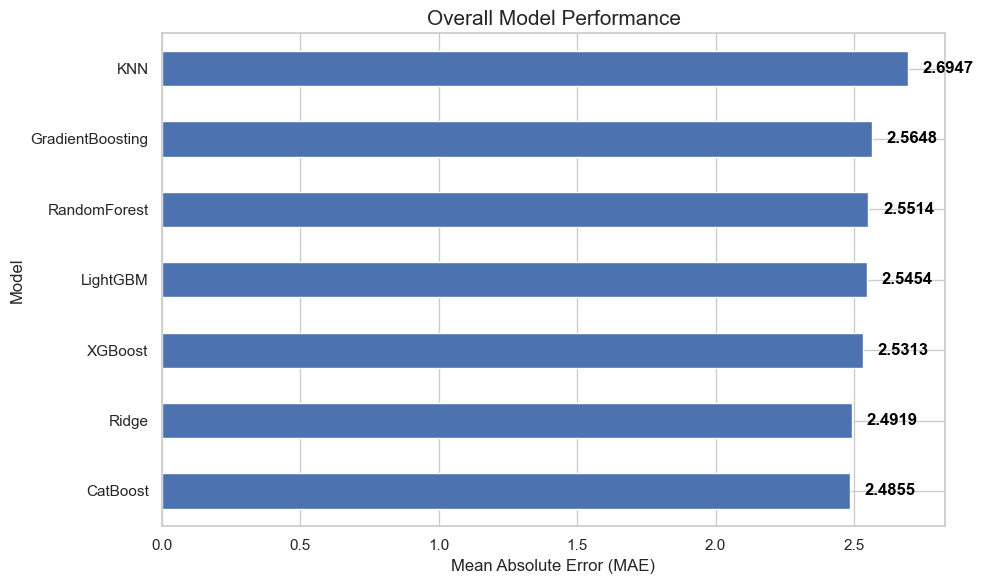

In [49]:
plot_model_comparison(ranking_avg)

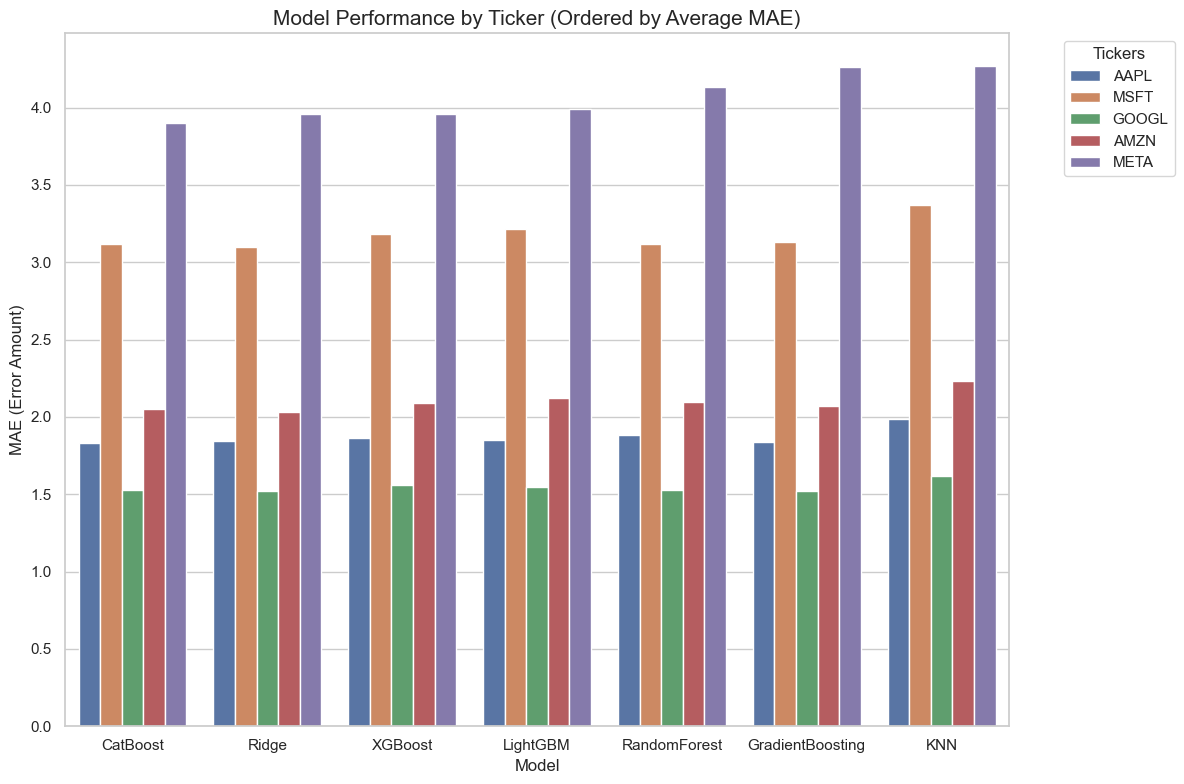

In [52]:
model_order = ranking_avg.index.tolist()
plot_ticker_performance_comparison(comparison_df, ranking_avg, model_order=model_order)

Ridge regression performed the best.

In [53]:
baseline_results = {}

for ticker in tickers:
    actuals = cleaned_val_dfs[ticker]['High_Diff']
    naive_preds = actuals.shift(1)
    
    valid_indices = naive_preds.dropna().index
    y_true = actuals.loc[valid_indices]
    y_naive = naive_preds.loc[valid_indices]
    
    baseline_mae = np.mean(np.abs(y_true - y_naive))
    baseline_results[ticker] = baseline_mae

    print(f"{ticker} Baseline MAE: {baseline_mae:.4f}")

AAPL Baseline MAE: 2.4383
MSFT Baseline MAE: 4.1871
GOOGL Baseline MAE: 2.0745
AMZN Baseline MAE: 2.7213
META Baseline MAE: 5.4394


Comparing to the baseline model, all models perform better.

In [ ]:
def objective(trial):
    regressor_name = trial.suggest_categorical(
        "model", ["Ridge", "CatBoost", "XGBoost"]
    )
    
    if regressor_name == "Ridge":
        model = Ridge(
            alpha=trial.suggest_float("ridge_alpha", 0.1, 1000.0, log=True),
            solver=trial.suggest_categorical("ridge_solver", ['auto', 'svd', 'cholesky', 'lsqr', 'sag']),
            random_state=42
        )

    elif regressor_name == "CatBoost":
        model = CatBoostRegressor(
            iterations=trial.suggest_int("cb_iterations", 100, 1000),
            learning_rate=trial.suggest_float("cb_learning_rate", 0.001, 0.1, log=True),
            depth=trial.suggest_int("cb_depth", 2, 10),
            l2_leaf_reg=trial.suggest_float("cb_l2_reg", 1.0, 20, log=True),
            subsample=trial.suggest_float("cb_subsample", 0.05, 1.0),
            random_strength=trial.suggest_float("cb_random_strength", 1e-9, 10, log=True),
            loss_function="MAE", 
            random_state=42,
            verbose=False
        )

    elif regressor_name == "XGBoost":
        model = XGBRegressor(
            n_estimators=trial.suggest_int("xgb_n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("xgb_learning_rate", 0.001, 0.1, log=True),
            max_depth=trial.suggest_int("xgb_max_depth", 3, 12),
            subsample=trial.suggest_float("xgb_subsample", 0.5, 1.0),
            min_child_weight=trial.suggest_int("xgb_min_child_weight", 1, 40),
            objective='reg:absoluteerror', 
            tree_method='hist',
            random_state=42,
            n_jobs=-1
        )

    pipeline = Pipeline([('prep', preprocessor), ('reg', model)])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    
    return mae

In [55]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print(f"Best Model: {study.best_params['model']}")
print(f"Best MAE: {study.best_value}")

[I 2026-05-12 21:37:35,986] A new study created in memory with name: no-name-0797528d-ef44-4df3-a9c7-afb9bb8484c0
[I 2026-05-12 21:37:41,335] Trial 0 finished with value: 2.4717899210546035 and parameters: {'model': 'XGBoost', 'xgb_n_estimators': 217, 'xgb_learning_rate': 0.01558529558069899, 'xgb_max_depth': 12, 'xgb_subsample': 0.6453405523893578, 'xgb_min_child_weight': 11}. Best is trial 0 with value: 2.4717899210546035.
[I 2026-05-12 21:37:41,416] Trial 1 finished with value: 2.491914932924375 and parameters: {'model': 'Ridge', 'ridge_alpha': 0.5698769493926342, 'ridge_solver': 'cholesky'}. Best is trial 0 with value: 2.4717899210546035.
[I 2026-05-12 21:37:47,815] Trial 2 finished with value: 2.470921506024432 and parameters: {'model': 'CatBoost', 'cb_iterations': 512, 'cb_learning_rate': 0.004862113919443627, 'cb_depth': 7, 'cb_l2_reg': 1.2729117216269628, 'cb_subsample': 0.535768055367996, 'cb_random_strength': 0.008681933612611934}. Best is trial 2 with value: 2.47092150602443

Best Model: CatBoost
Best MAE: 2.467666653924772


In [57]:
ridge_best = get_best_params_for_model(study, "Ridge")
cat_best = get_best_params_for_model(study, "CatBoost")
xgb_best = get_best_params_for_model(study, "XGBoost")

In [61]:
model1 = Ridge(
    **clean_params(ridge_best['params'], 'ridge_'), 
    random_state=42
)

cleaned_cb_params = clean_params(cat_best['params'], 'cb_')
if 'l2_reg' in cleaned_cb_params:
    cleaned_cb_params['l2_leaf_reg'] = cleaned_cb_params.pop('l2_reg')

model2 = CatBoostRegressor(
    **cleaned_cb_params,
    loss_function='MAE', 
    verbose=False,
    random_state=42
)

model3 = XGBRegressor(
    **clean_params(xgb_best['params'], 'xgb_'),
    objective='reg:absoluteerror',
    tree_method='hist',
    random_state=42
)

In [62]:
ensemble = VotingRegressor(estimators=[
    ('ridge', model1),
    ('cat', model2),
    ('xgb', model3)
])

pipeline_ensemble_3 = Pipeline([('prep', preprocessor), ('reg', ensemble)])

pipeline_ensemble_3.fit(X_train, y_train)
y_pred_ensemble_3 = pipeline_ensemble_3.predict(X_val)

Ensemble Voting Regressor MAE: 2.469942


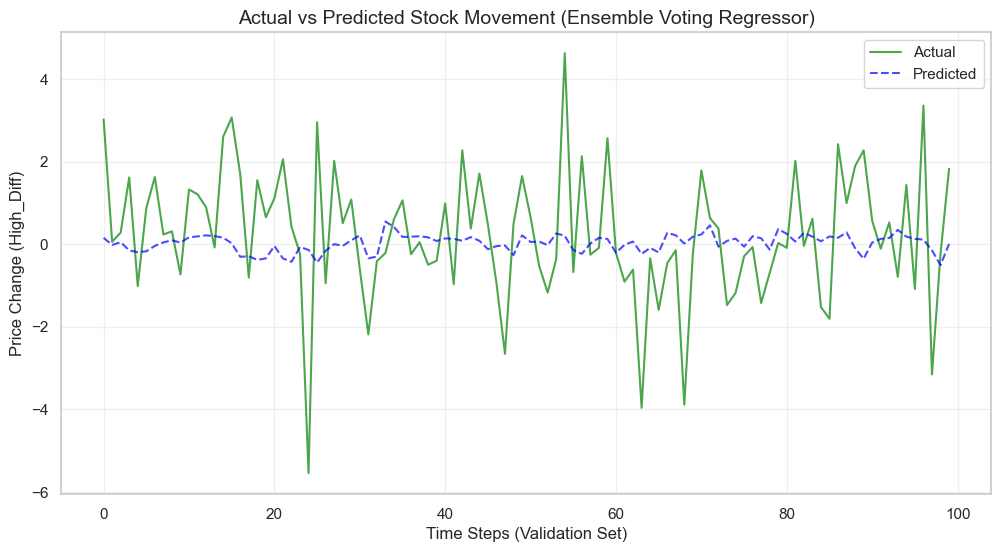

In [68]:
evaluate_ensemble(y_val, y_pred_ensemble_3)

In [69]:
ensemble = VotingRegressor(estimators=[
    ('cat', model2),
    ('xgb', model3)
])

pipeline_ensemble_2 = Pipeline([('prep', preprocessor), ('reg', ensemble)])

pipeline_ensemble_2.fit(X_train, y_train)
y_pred_ensemble_2 = pipeline_ensemble_2.predict(X_val)

Ensemble Voting Regressor MAE: 2.466422


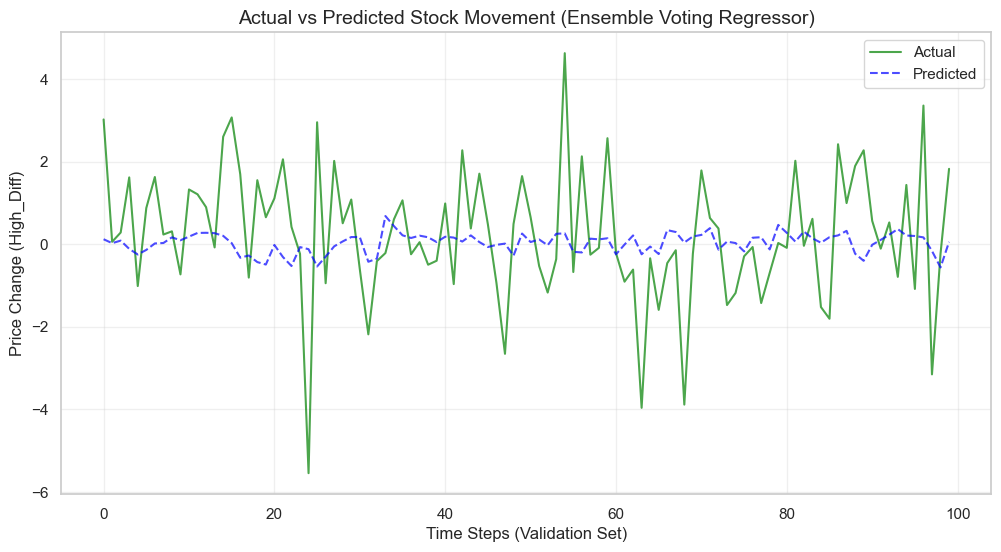

In [70]:
evaluate_ensemble(y_val, y_pred_ensemble_2)

In [71]:
stack_ensemble = StackingRegressor(
    estimators=[('cat', model2), ('xgb', model3)],
    final_estimator=Ridge()
)

pipeline_stack_ensemble = Pipeline([('prep', preprocessor), ('reg', stack_ensemble)])

pipeline_stack_ensemble.fit(X_train, y_train)
y_pred_stack_ensemble = pipeline_stack_ensemble.predict(X_val)

Ensemble Voting Regressor MAE: 2.473543


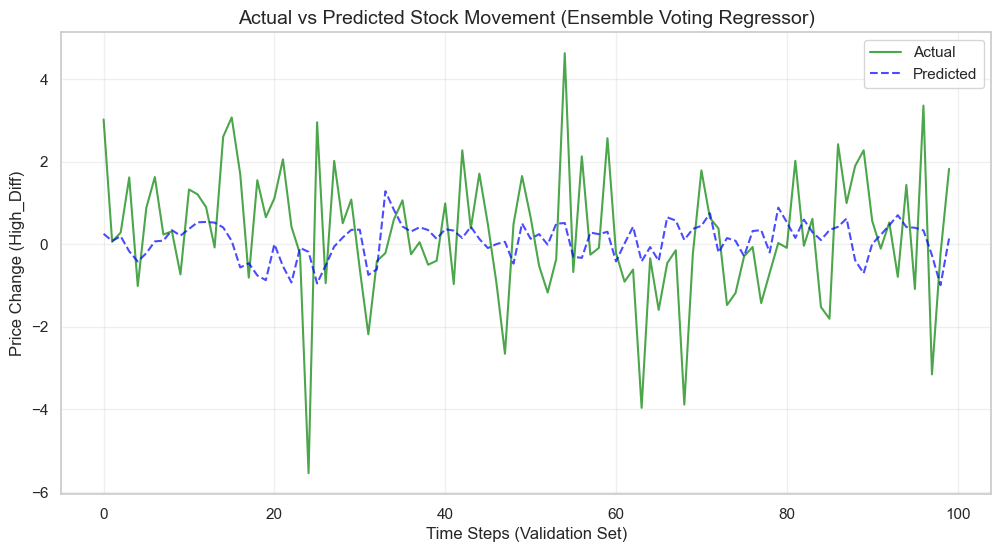

In [72]:
evaluate_ensemble(y_val, y_pred_stack_ensemble)

best model so far.

# Survival analysis

In [80]:
all_survival_data = []
threshold = 0.05


for ticker, df in cleaned_train_dfs.items():
    df = df.copy()
    df['Ticker'] = ticker

    df['Vol_7d'] = df['High_Diff'].rolling(window=7).std()
    df['SMA_20'] = df['Original_High'].rolling(window=20).mean()
    df['Dist_SMA_20'] = (df['Original_High'] / df['SMA_20']) - 1

    delta = df['High_Diff']
    up = delta.clip(lower=0).rolling(window=14).mean()
    down = -delta.clip(upper=0).rolling(window=14).mean()
    rs = up / down.replace(0, np.nan)
    df['RSI'] = 100 - (100 / (1 + rs))
    df['RSI'] = df['RSI'].fillna(50)
    df['Vol_Mean_20'] = df['Volume'].rolling(window=20).mean()
    df['Vol_Std_20'] = df['Volume'].rolling(window=20).std()
    df['Vol_ZScore'] = (df['Volume'] - df['Vol_Mean_20']) / (df['Vol_Std_20'] + 1e-9)

    ema_12 = df['Original_High'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Original_High'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26

    df['Upper_BB'] = df['SMA_20'] + (2 * df['Vol_7d'])
    df['Lower_BB'] = df['SMA_20'] - (2 * df['Vol_7d'])
    df['BB_Percent'] = (df['Original_High'] - df['Lower_BB']) / (df['Upper_BB'] - df['Lower_BB'] + 1e-9)

    for lag in range(1, 8):
        df[f'lag_{lag}'] = df['High_Diff'].shift(lag)

    prev_close = df['Original_High'] - df['High_Diff']
    df['Daily_Pct_Return'] = df['High_Diff'] / prev_close

    returns = df['Daily_Pct_Return'].values

    n = len(returns)
    durations = np.zeros(n)
    events = np.zeros(n)

    for i in range(n):
        future_returns = returns[i+1:]
        hits = np.where(future_returns >= threshold)[0]

        if len(hits) > 0:
            durations[i] = hits[0] + 1
            events[i] = 1
        else:
            durations[i] = len(future_returns)
            events[i] = 0

    df['Duration'] = durations
    df['Event'] = events

    all_survival_data.append(df)

master_surv_df = pd.concat(all_survival_data)
master_surv_df.dropna(inplace=True)
master_surv_df = master_surv_df[master_surv_df['Duration'] > 0]

daily_market_avg = master_surv_df.groupby(level=0)['High_Diff'].transform('mean')
master_surv_df['Relative_Performance'] = master_surv_df['High_Diff'] - daily_market_avg

master_surv_df = master_surv_df.reset_index()

print(f"Survival Master DF Shape: {master_surv_df.shape}")
print(master_surv_df[['Ticker', 'Duration', 'Event']].head()) 

Survival Master DF Shape: (13591, 27)
  Ticker  Duration  Event
0   AAPL     499.0    1.0
1   AAPL     498.0    1.0
2   AAPL     497.0    1.0
3   AAPL     496.0    1.0
4   AAPL     495.0    1.0


In [81]:
all_features = ['Ticker', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 
                'Vol_7d', 'Dist_SMA_20', 'RSI', 'Vol_ZScore', 'MACD', 'BB_Percent', 'Relative_Performance']

X_surv = master_surv_df[all_features]
y_surv = master_surv_df[['Event', 'Duration']]

In [82]:
y_survival = np.array(
    list(zip(master_surv_df['Event'].astype(bool), master_surv_df['Duration'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)

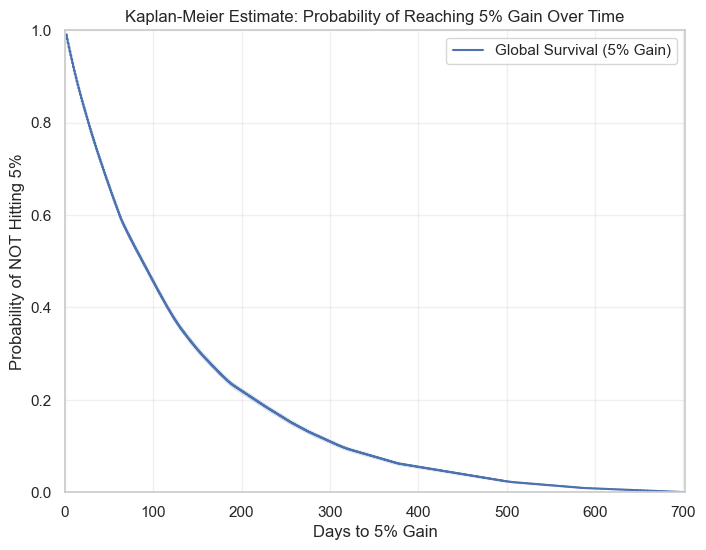

In [93]:
time_points, survival_probs = plot_kaplan_meier(master_surv_df, threshold_label="5%")

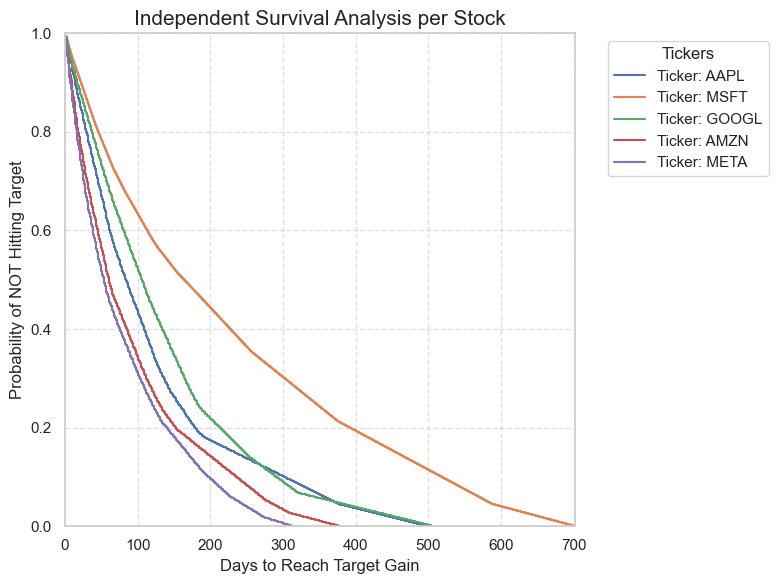

In [97]:
plot_ticker_survival_comparison(master_surv_df)

In [ ]:
y_surv = np.array(
    list(zip(master_surv_df['Event'].astype(bool), master_surv_df['Duration'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)

X_surv = pd.get_dummies(master_surv_df[all_features], columns=['Ticker'])

In [98]:
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X_surv, y_surv)

,n_estimators,100
,max_depth,None
,min_samples_split,10
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


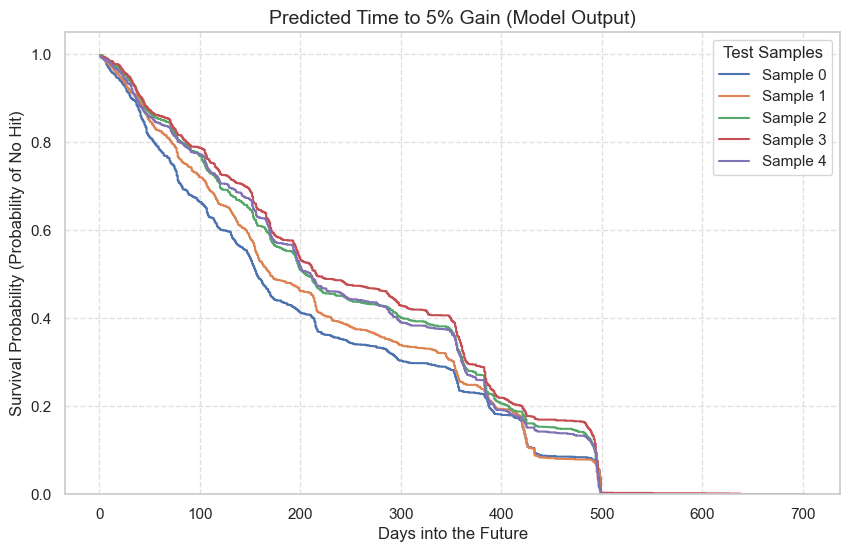

In [101]:
X_test_samples = X_surv.iloc[:5]
plot_rsf_predictions(rsf, X_test_samples)

In [ ]:
prediction = rsf.predict(X_surv)
result = concordance_index_censored(y_surv["Status"], y_surv["Time"], prediction)

print(f"C-index of the Global Model: {result[0]:.4f}")

C-index of the Global Model: 0.7075


# Ranking model

In [ ]:
master_train_df = master_train_df.reset_index()
master_train_df = prep_ranking_data(master_train_df)

market_context = master_train_df.groupby('Date')['High_Diff'].agg(['mean', 'std']).rename(
    columns={'mean': 'Market_Return', 'std': 'Market_Vol'}
)

master_train_df = master_train_df.merge(market_context, on='Date', how='left')

features = [col for col in master_train_df.columns if 'lag' in col or '_rel' in col] 
features += ['Vol_7d', 'Market_Return', 'Market_Vol']

X = master_train_df[features]
y = master_train_df['relevance']
groups = master_train_df.groupby('Date').size().to_list()

ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    importance_type="gain",
    learning_rate=0.05,
    n_estimators=100,
    label_gain=[0, 1, 3, 7, 15]
)

ranker.fit(
    X, y, 
    group=groups,
    eval_at=[1, 3]
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [109]:
market_context = master_val_df.groupby('Date')['High_Diff'].agg(['mean', 'std']).rename(
    columns={'mean': 'Market_Return', 'std': 'Market_Vol'}
)
master_val_df = master_val_df.merge(market_context, on='Date', how='left')

master_val_df = master_val_df.reset_index()
master_val_df = prep_ranking_data(master_val_df)

master_val_df['pred_score'] = ranker.predict(master_val_df[features])
acc = master_val_df.groupby('Date').apply(pairwise_accuracy).mean()
print(f"Average Pairwise Accuracy: {acc:.2%}")

Average Pairwise Accuracy: 67.92%


data prep: 
- query item pairs (?)
- features (about query, items, query-item interactions)
- group items by query for modelling
- handle imbalanced relevance labels

cross-sectional z-scores

adding query context

grouping

handling imbalances

pairwise ranking vs pointwise ranking. metrics: precision@k, mean average precision, NDCG, MRR

In [110]:
market_context_test = master_test_df.groupby('Date')['High_Diff'].agg(['mean', 'std']).rename(
    columns={'mean': 'Market_Return', 'std': 'Market_Vol'}
)
master_test_df = master_test_df.merge(market_context_test, on='Date', how='left')

master_test_df = master_test_df.reset_index()
master_test_df = prep_ranking_data(master_test_df)

X_test_processed = master_test_df[features] 

master_test_df['pred_score'] = ranker.predict(X_test_processed)

acc = master_test_df.groupby('Date').apply(pairwise_accuracy).mean()
print(f"Average Pairwise Accuracy: {acc:.2%}")

Average Pairwise Accuracy: 67.20%
